In [21]:
def plot_style(title):
    plt.title(title)
    plt.tight_layout()

# Retail Sales Forecasting

## Exploratory Data Analysis (EDA)

In [5]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import psycopg2
from sqlalchemy import create_engine

pd.set_option("display.max_columns", None)

plt.style.use("ggplot")

In [8]:
from sqlalchemy import create_engine
from sqlalchemy.engine import URL

connection_url = URL.create(
    drivername="postgresql+psycopg2",
    username="postgres",
    password="Rahulydv@3171",
    host="localhost",
    port=5432,
    database="retail_sales",
)

engine = create_engine(connection_url)

In [9]:
sales = pd.read_sql(
    "SELECT * FROM sales LIMIT 5",
    engine,
)

sales

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


In [10]:
stores = pd.read_sql("SELECT * FROM stores", engine)
transactions = pd.read_sql("SELECT * FROM transactions", engine)
oil = pd.read_sql("SELECT * FROM oil_prices", engine)
holidays = pd.read_sql("SELECT * FROM holidays", engine)

print("Sales:", sales.shape)
print("Stores:", stores.shape)
print("Transactions:", transactions.shape)
print("Oil:", oil.shape)
print("Holidays:", holidays.shape)

Sales: (5, 6)
Stores: (54, 5)
Transactions: (83488, 4)
Oil: (1218, 2)
Holidays: (350, 7)


## Data Overview

In [12]:
datasets = {
    "Sales": sales,
    "Stores": stores,
    "Transactions": transactions,
    "Oil": oil,
    "Holidays": holidays,
}

In [13]:
for name, df in datasets.items():
    print("=" * 70)
    print(name.upper())
    print("=" * 70)

    print("\nShape:")
    print(df.shape)

    print("\nColumns:")
    print(df.columns.tolist())

    print("\nData Types:")
    print(df.dtypes)

    print("\nMissing Values:")
    print(df.isnull().sum())

    print("\nDuplicate Rows:")
    print(df.duplicated().sum())

    print("\n")

SALES

Shape:
(5, 6)

Columns:
['id', 'date', 'store_nbr', 'family', 'sales', 'onpromotion']

Data Types:
id               int64
date            object
store_nbr        int64
family             str
sales          float64
onpromotion      int64
dtype: object

Missing Values:
id             0
date           0
store_nbr      0
family         0
sales          0
onpromotion    0
dtype: int64

Duplicate Rows:
0


STORES

Shape:
(54, 5)

Columns:
['store_nbr', 'city', 'state', 'store_type', 'cluster']

Data Types:
store_nbr     int64
city            str
state           str
store_type      str
cluster       int64
dtype: object

Missing Values:
store_nbr     0
city          0
state         0
store_type    0
cluster       0
dtype: int64

Duplicate Rows:
0


TRANSACTIONS

Shape:
(83488, 4)

Columns:
['id', 'date', 'store_nbr', 'transactions']

Data Types:
id               int64
date            object
store_nbr        int64
transactions     int64
dtype: object

Missing Values:
id              0
da

## Store Distribution

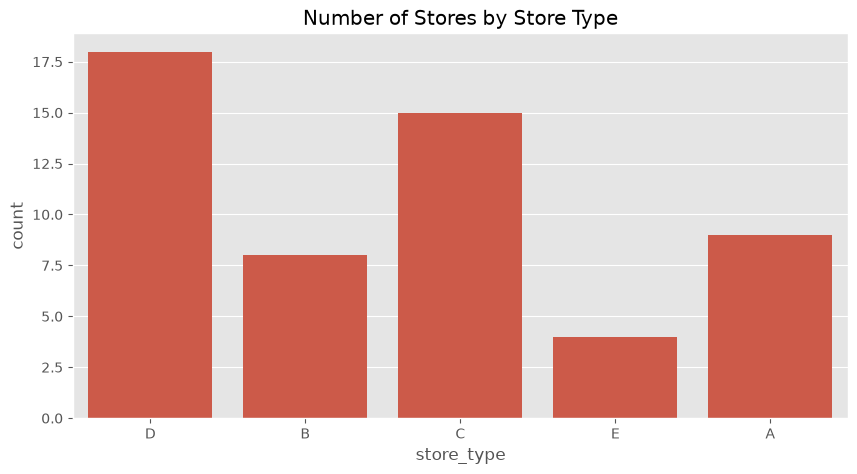

In [14]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=stores,
    x="store_type"
)

plt.title("Number of Stores by Store Type")
plt.show()

## Dataset Summary

In [15]:
for name, df in datasets.items():
    print("=" * 70)
    print(name)
    print("=" * 70)

    display(df.head())

    print("\nShape :", df.shape)
    print("\nData Types")
    display(df.dtypes)

    print("\nMissing Values")
    display(df.isnull().sum())

    print("\nDuplicate Rows :", df.duplicated().sum())

    print("\n")

Sales


,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0



Shape : (5, 6)

Data Types


id               int64
date            object
store_nbr        int64
family             str
sales          float64
onpromotion      int64
dtype: object


Missing Values


...


Shape : (350, 7)

Data Types


id               int64
date            object
holiday_type       str
locale             str
locale_name        str
description        str
transferred       bool
dtype: object


Missing Values


id              0
date            0
holiday_type    0
locale          0
locale_name     0
description     0
transferred     0
dtype: int64


Duplicate Rows : 0




## Statistical Summary

In [16]:
for name, df in datasets.items():
    print("=" * 70)
    print(name)
    print("=" * 70)

    display(df.describe(include="all"))

Sales


,id,date,store_nbr,family,sales,onpromotion
count,5.000000,5,5.0,5,5.0,5.0
unique,NaN,1,NaN,5,NaN,NaN
top,NaN,2013-01-01,NaN,AUTOMOTIVE,NaN,NaN
freq,NaN,5,NaN,1,NaN,NaN
mean,2.000000,NaN,1.0,NaN,0.0,0.0
std,1.581139,NaN,0.0,NaN,0.0,0.0
min,0.000000,NaN,1.0,NaN,0.0,0.0
25%,1.000000,NaN,1.0,NaN,0.0,0.0
50%,2.000000,NaN,1.0,NaN,0.0,0.0
75%,3.000000,NaN,1.0,NaN,0.0,0.0


Stores


,store_nbr,city,state,store_type,cluster
count,54.000000,54,54,54,54.000000
unique,NaN,22,16,5,NaN
top,NaN,Quito,Pichincha,D,NaN
freq,NaN,18,19,18,NaN
mean,27.500000,NaN,NaN,NaN,8.481481
std,15.732133,NaN,NaN,NaN,4.693395
min,1.000000,NaN,NaN,NaN,1.000000
25%,14.250000,NaN,NaN,NaN,4.000000
50%,27.500000,NaN,NaN,NaN,8.500000
75%,40.750000,NaN,NaN,NaN,13.000000


Transactions


,id,date,store_nbr,transactions
count,83488.000000,83488,83488.000000,83488.000000
unique,NaN,1682,NaN,NaN
top,NaN,2017-04-20,NaN,NaN
freq,NaN,54,NaN,NaN
mean,41744.500000,NaN,26.939237,1694.602158
std,24101.053974,NaN,15.608204,963.286644
min,1.000000,NaN,1.000000,5.000000
25%,20872.750000,NaN,13.000000,1046.000000
50%,41744.500000,NaN,27.000000,1393.000000
75%,62616.250000,NaN,40.000000,2079.000000


Oil


,date,dcoilwtico
count,1218,1175.000000
unique,1218,NaN
top,2013-01-01,NaN
freq,1,NaN
mean,NaN,67.714366
std,NaN,25.630476
min,NaN,26.190000
25%,NaN,46.405000
50%,NaN,53.190000
75%,NaN,95.660000


Holidays


,id,date,holiday_type,locale,locale_name,description,transferred
count,350.000000,350,350,350,350,350,350
unique,NaN,312,6,3,24,103,2
top,NaN,2014-06-25,Holiday,National,Ecuador,Carnaval,False
freq,NaN,4,221,174,174,10,338
mean,175.500000,NaN,NaN,NaN,NaN,NaN,NaN
std,101.180532,NaN,NaN,NaN,NaN,NaN,NaN
min,1.000000,NaN,NaN,NaN,NaN,NaN,NaN
25%,88.250000,NaN,NaN,NaN,NaN,NaN,NaN
50%,175.500000,NaN,NaN,NaN,NaN,NaN,NaN
75%,262.750000,NaN,NaN,NaN,NaN,NaN,NaN


## Missing Value Analysis

In [17]:
missing = (
    pd.DataFrame({
        "Missing Values": oil.isnull().sum(),
        "Percentage": (
            oil.isnull().sum() / len(oil) * 100
        ).round(2)
    })
)

missing

,Missing Values,Percentage
date,0,0.00
dcoilwtico,43,3.53


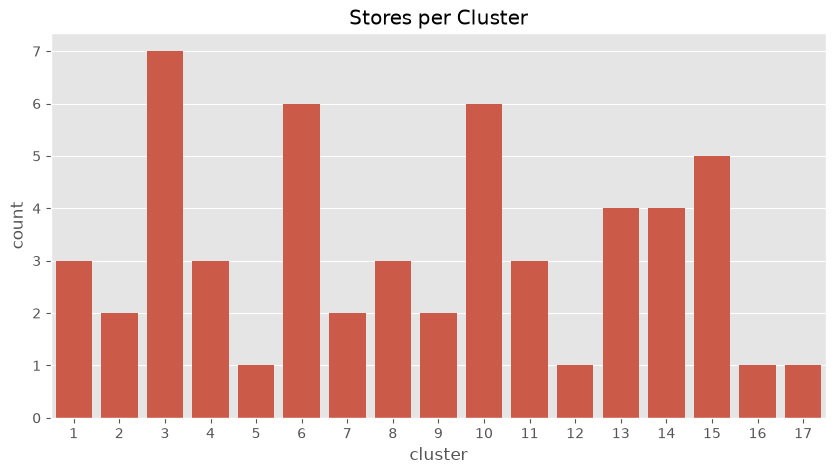

In [18]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=stores,
    x="cluster"
)

plt.title("Stores per Cluster")
plt.show()

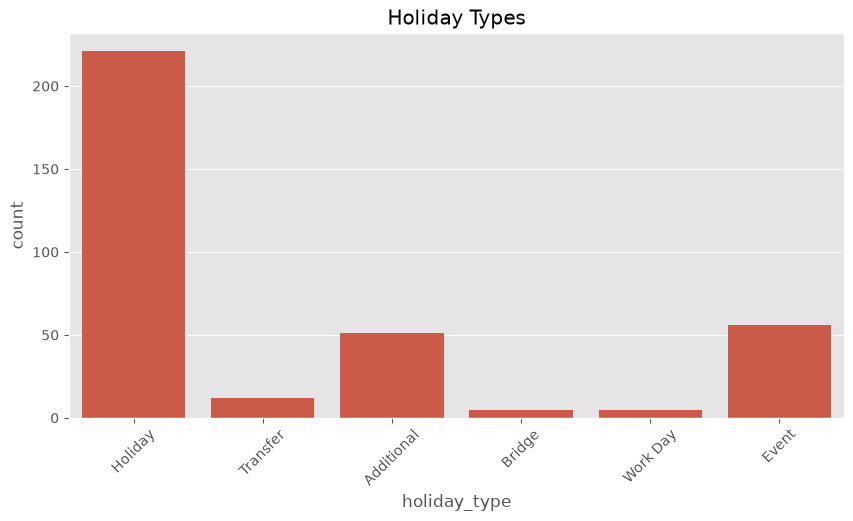

In [19]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=holidays,
    x="holiday_type"
)

plt.xticks(rotation=45)

plt.title("Holiday Types")

plt.show()

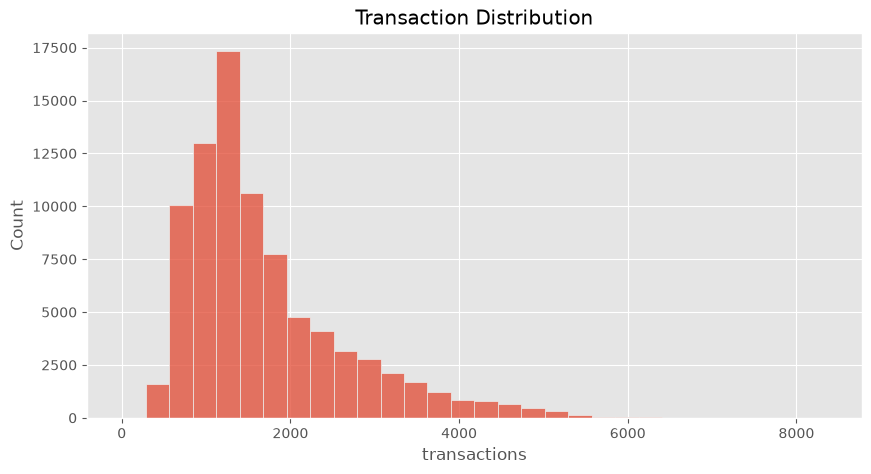

In [20]:
plt.figure(figsize=(10,5))

sns.histplot(
    transactions["transactions"],
    bins=30
)

plt.title("Transaction Distribution")

plt.show()

## Sales Trend Over Time

In [23]:
sales_sample = pd.read_sql("""
SELECT *
FROM sales
LIMIT 100000;
""", engine)

sales_sample.head()

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


In [24]:
sales_sample["date"] = pd.to_datetime(sales_sample["date"])

In [25]:
daily_sales = (
    sales_sample
    .groupby("date")["sales"]
    .sum()
    .reset_index()
)

daily_sales.head()

,date,sales
0,2013-01-01,2511.62
1,2013-01-02,496092.50
2,2013-01-03,361461.28
3,2013-01-04,354459.74
4,2013-01-05,477350.26


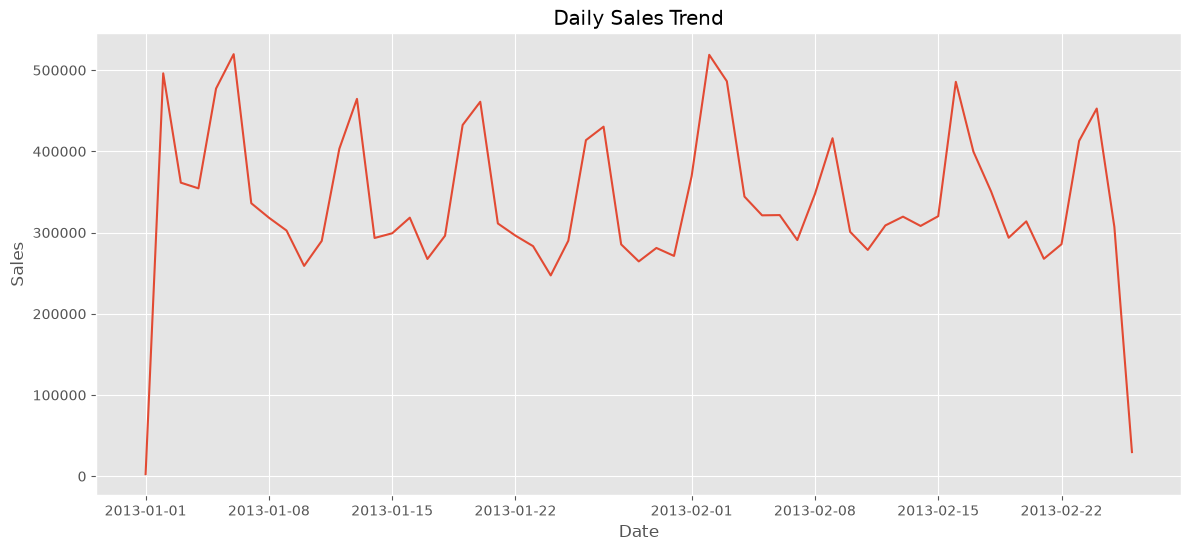

In [26]:
plt.figure(figsize=(14,6))

plt.plot(
    daily_sales["date"],
    daily_sales["sales"]
)

plt.title("Daily Sales Trend")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.show()

## Product Family Analysis

In [27]:
family_sales = (
    sales_sample
    .groupby("family")["sales"]
    .sum()
    .sort_values(ascending=False)
)

family_sales.head(10)

family
GROCERY I        7626695.00
BEVERAGES        3054323.00
CLEANING         2645131.00
BREAD/BAKERY     1005522.54
DAIRY             979194.00
MEATS             969318.70
PERSONAL CARE     569750.00
POULTRY           566365.91
DELI              564415.17
EGGS              378384.00
Name: sales, dtype: float64

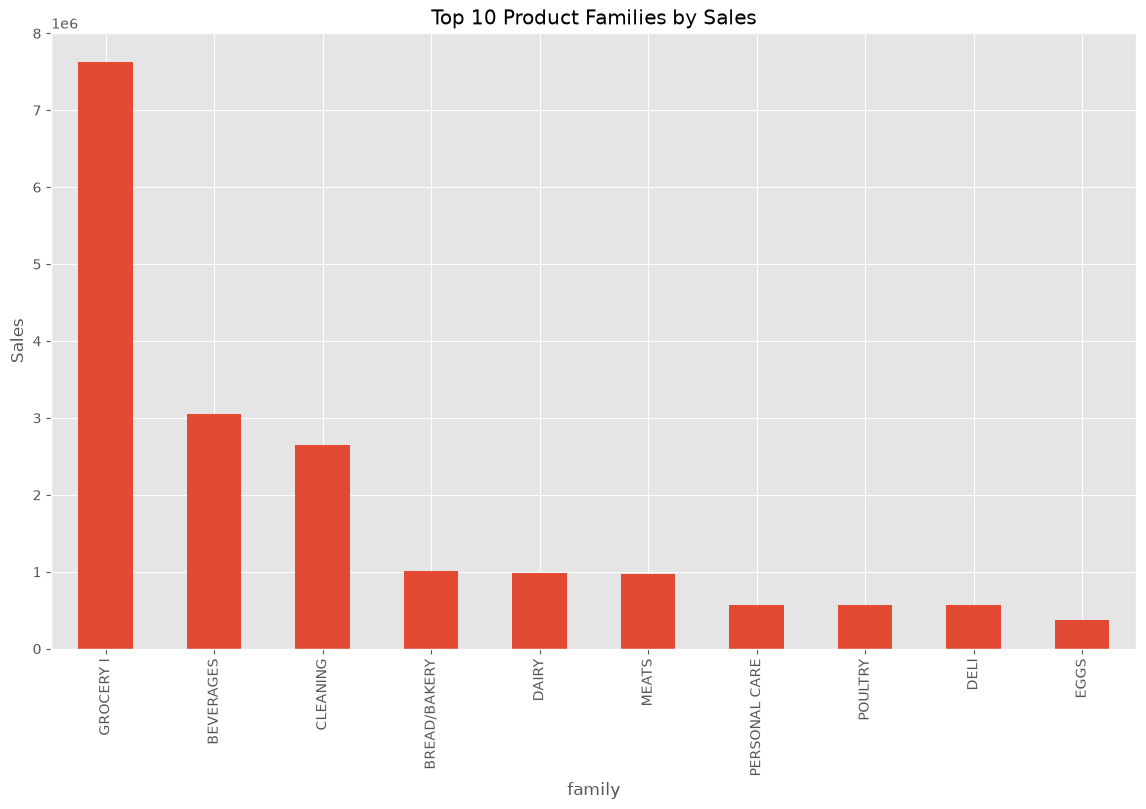

In [28]:
plt.figure(figsize=(14,8))

family_sales.head(10).plot(kind="bar")

plt.title("Top 10 Product Families by Sales")

plt.ylabel("Sales")

plt.show()

In [29]:
promotion_sales = (
    sales_sample
    .groupby("onpromotion")["sales"]
    .mean()
)

promotion_sales

onpromotion
0    191.793452
Name: sales, dtype: float64

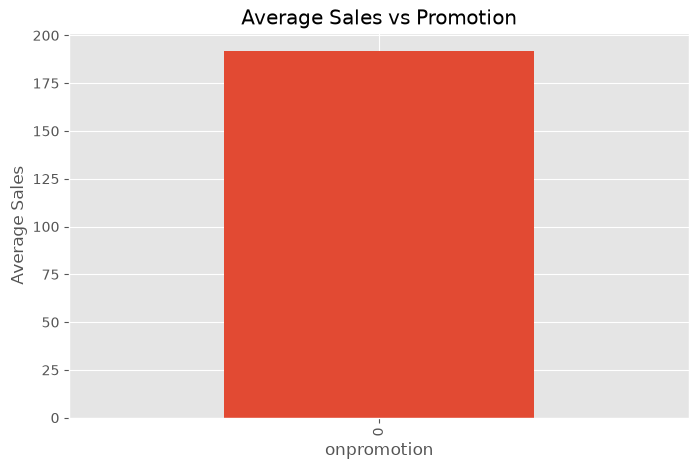

In [30]:
promotion_sales.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Average Sales vs Promotion")

plt.ylabel("Average Sales")

plt.show()

In [31]:
numeric_df = sales_sample.select_dtypes(include="number")

numeric_df.corr()

,id,store_nbr,sales,onpromotion
id,1.000000,0.005079,0.002628,NaN
store_nbr,0.005079,1.000000,0.023978,NaN
sales,0.002628,0.023978,1.000000,NaN
onpromotion,NaN,NaN,NaN,NaN


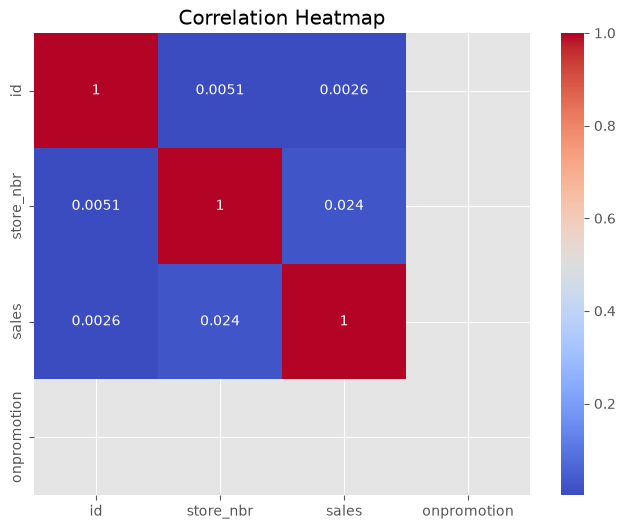

In [32]:
plt.figure(figsize=(8,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

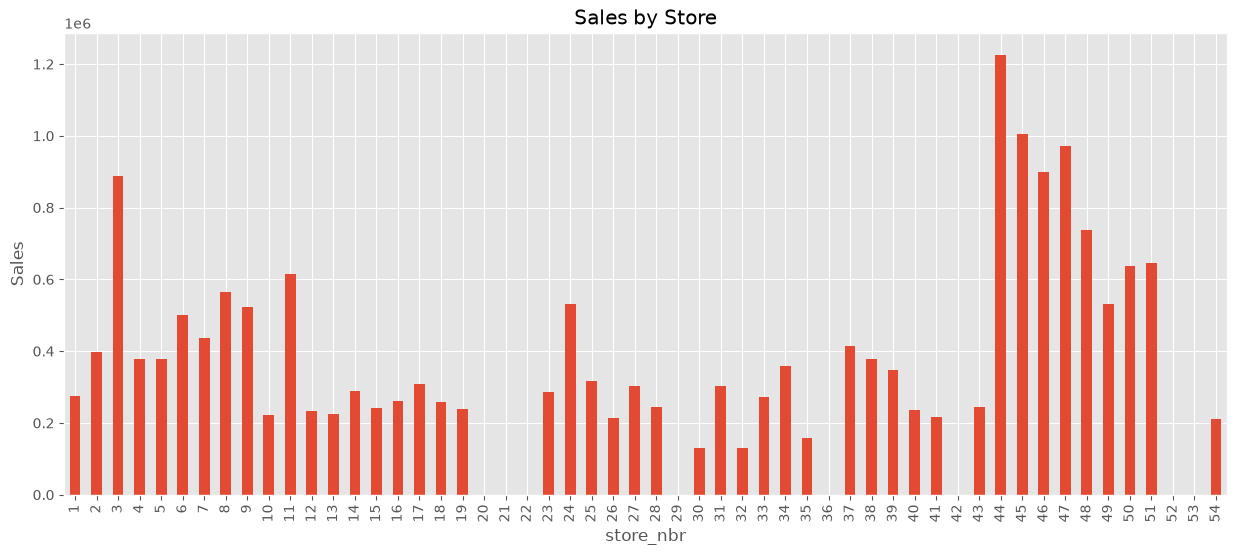

In [33]:
store_sales = (
    sales_sample
    .groupby("store_nbr")["sales"]
    .sum()
)

plt.figure(figsize=(15,6))

store_sales.plot(kind="bar")

plt.title("Sales by Store")

plt.ylabel("Sales")

plt.show()

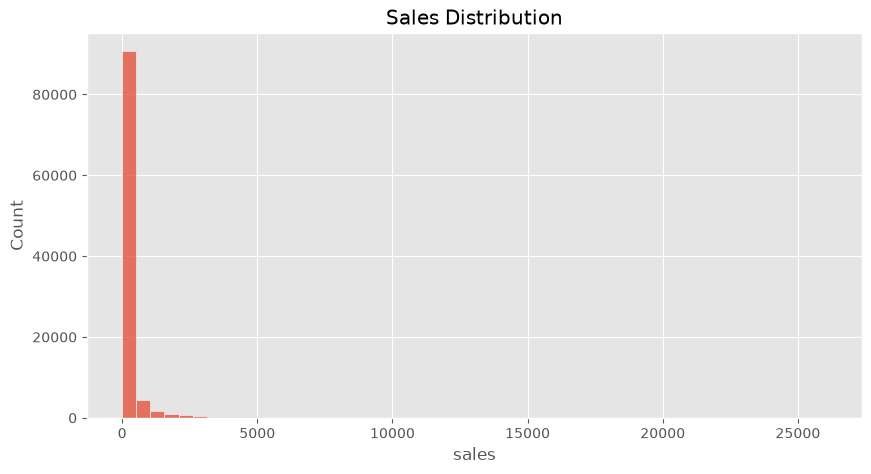

In [34]:
plt.figure(figsize=(10,5))

sns.histplot(
    sales_sample["sales"],
    bins=50
)

plt.title("Sales Distribution")

plt.show()

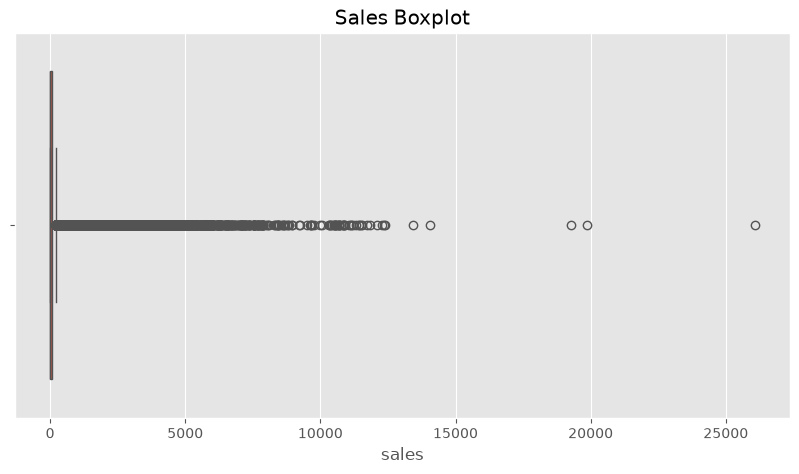

In [35]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x=sales_sample["sales"]
)

plt.title("Sales Boxplot")

plt.show()

In [36]:
print("Minimum Date :", sales_sample["date"].min())
print("Maximum Date :", sales_sample["date"].max())

Minimum Date : 2013-01-01 00:00:00
Maximum Date : 2013-02-26 00:00:00


# Key Insights

### Stores
- 54 stores
- Store type D has the highest number of stores.

### Transactions
- No duplicate rows.
- Large variation in transactions.

### Oil
- Contains missing values.

### Holidays
- Multiple holiday categories.
- No major data quality issues.

### Sales
- Strong skewness.
- Presence of outliers.
- Sales vary significantly across product families.
- Promotions influence sales.

In [1]:
print("Hello")

Hello


In [3]:
import pandas as pd

featured = pd.read_csv(
    "../data/featured/featured_sales.csv",
    nrows=5,
)

print(featured.columns.tolist())

['id', 'date', 'store_nbr', 'family', 'sales', 'onpromotion', 'year', 'month', 'day', 'day_of_week', 'week_of_year', 'quarter', 'is_weekend', 'transactions', 'dcoilwtico', 'type', 'locale', 'locale_name', 'description', 'transferred']


In [5]:
for col in featured.columns:
    print(col)

id
date
store_nbr
family
sales
onpromotion
year
month
day
day_of_week
week_of_year
quarter
is_weekend
transactions
dcoilwtico
type
locale
locale_name
description
transferred


In [6]:
holiday_cols = [
    "type",
    "locale",
    "locale_name",
    "description",
    "transferred",
]

for col in holiday_cols:
    print(col, "->", col in featured.columns)

type -> True
locale -> True
locale_name -> True
description -> True
transferred -> True


In [7]:
featured = pd.read_csv(
    "../data/featured/featured_sales.csv",
    nrows=20,
)

print(featured.columns.tolist())

['id', 'date', 'store_nbr', 'family', 'sales', 'onpromotion', 'year', 'month', 'day', 'day_of_week', 'week_of_year', 'quarter', 'is_weekend', 'transactions', 'dcoilwtico', 'type', 'locale', 'locale_name', 'description', 'transferred', 'lag_1', 'lag_7']


In [8]:
[col for col in featured.columns if "lag" in col]

['lag_1', 'lag_7']

In [9]:
featured[["store_nbr", "family", "date", "sales", "lag_1", "lag_7"]].head(15)

,store_nbr,family,date,sales,lag_1,lag_7
0,1,AUTOMOTIVE,2013-01-01,0.0,NaN,NaN
1,1,AUTOMOTIVE,2013-01-02,2.0,0.0,NaN
2,1,AUTOMOTIVE,2013-01-03,3.0,2.0,NaN
3,1,AUTOMOTIVE,2013-01-04,3.0,3.0,NaN
4,1,AUTOMOTIVE,2013-01-05,5.0,3.0,NaN
5,1,AUTOMOTIVE,2013-01-06,2.0,5.0,NaN
6,1,AUTOMOTIVE,2013-01-07,0.0,2.0,NaN
7,1,AUTOMOTIVE,2013-01-08,2.0,0.0,0.0
8,1,AUTOMOTIVE,2013-01-09,2.0,2.0,2.0
9,1,AUTOMOTIVE,2013-01-10,2.0,2.0,3.0


In [10]:
print("rolling_mean_7" in featured.columns)
print("rolling_std_7" in featured.columns)

False
False


In [11]:
import pandas as pd

featured = pd.read_csv("../data/featured/featured_sales.csv")

print(featured.shape)

print(featured.columns.tolist())

(3054348, 24)
['id', 'date', 'store_nbr', 'family', 'sales', 'onpromotion', 'year', 'month', 'day', 'day_of_week', 'week_of_year', 'quarter', 'is_weekend', 'transactions', 'dcoilwtico', 'type', 'locale', 'locale_name', 'description', 'transferred', 'lag_1', 'lag_7', 'rolling_mean_7', 'rolling_std_7']


In [12]:
featured.tail()

,id,date,store_nbr,family,sales,onpromotion,year,month,day,day_of_week,...,dcoilwtico,type,locale,locale_name,description,transferred,lag_1,lag_7,rolling_mean_7,rolling_std_7
3054343,2993627,2017-08-11,54,SEAFOOD,0.0,0,2017,8,11,4,...,48.81,Transfer,National,Ecuador,Traslado Primer Grito de Independencia,False,2.0,0.0,3.000000,4.281744
3054344,2995409,2017-08-12,54,SEAFOOD,1.0,1,2017,8,12,5,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,3.0,3.000000,4.281744
3054345,2997191,2017-08-13,54,SEAFOOD,2.0,0,2017,8,13,6,...,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.0,2.714286,4.347961
3054346,2998973,2017-08-14,54,SEAFOOD,0.0,0,2017,8,14,0,...,47.59,NaN,NaN,NaN,NaN,NaN,2.0,0.0,3.000000,4.203173
3054347,3000755,2017-08-15,54,SEAFOOD,3.0,0,2017,8,15,1,...,47.57,Holiday,Local,Riobamba,Fundacion de Riobamba,False,0.0,12.0,3.000000,4.203173


In [13]:
featured.columns.tolist()

['id',
 'date',
 'store_nbr',
 'family',
 'sales',
 'onpromotion',
 'year',
 'month',
 'day',
 'day_of_week',
 'week_of_year',
 'quarter',
 'is_weekend',
 'transactions',
 'dcoilwtico',
 'type',
 'locale',
 'locale_name',
 'description',
 'transferred',
 'lag_1',
 'lag_7',
 'rolling_mean_7',
 'rolling_std_7']

In [14]:
print("lag_1:", "lag_1" in featured.columns)
print("lag_7:", "lag_7" in featured.columns)
print("rolling_mean_7:", "rolling_mean_7" in featured.columns)
print("rolling_std_7:", "rolling_std_7" in featured.columns)

lag_1: True
lag_7: True
rolling_mean_7: True
rolling_std_7: True


In [15]:
featured = pd.read_csv("../data/featured/featured_sales.csv")

print("city" in featured.columns)
print("state" in featured.columns)
print("store_type" in featured.columns)
print("cluster" in featured.columns)

True
True
False
True


In [16]:
print("type" in featured.columns)

False


In [17]:
import pandas as pd

stores = pd.read_csv("../data/raw/stores.csv")

print(stores.columns.tolist())

['store_nbr', 'city', 'state', 'type', 'cluster']


In [18]:
stores.head()

,store_nbr,city,state,type,cluster
0,1,Quito,Pichincha,D,13
1,2,Quito,Pichincha,D,13
2,3,Quito,Pichincha,D,8
3,4,Quito,Pichincha,D,9
4,5,Santo Domingo,Santo Domingo de los Tsachilas,D,4


In [19]:
[col for col in featured.columns if "store" in col.lower()]

['store_nbr']

In [21]:
print("store_type" in featured.columns)

False


In [22]:
featured = pd.read_csv("../data/featured/featured_sales.csv")

for col in featured.columns:
    print(col)

id
date
store_nbr
family
sales
onpromotion
year
month
day
day_of_week
week_of_year
quarter
is_weekend
transactions
dcoilwtico
type
locale
locale_name
description
transferred
city
state
store_type
cluster
lag_1
lag_7
rolling_mean_7
rolling_std_7
